<a href="https://colab.research.google.com/github/Lost-Pawn/ml-models/blob/feature/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

LOAD DATASET

In [19]:
df = pd.read_csv("housing.csv")

INSPECT DATASET

In [23]:
data

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903
...,...,...,...,...,...
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379


In [21]:
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [13]:
df.shape

(10000, 5)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [17]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


SEPERATE FEATURES AND TARGET

In [18]:
x = df.drop("price", axis=1)
y = df["price"]

SPLIT DATASET

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

CREATING MODEL

In [27]:
model = LinearRegression()

TRAINING MODEL

In [29]:
model.fit(x_train,y_train)

LinearRegression()

In [31]:
print(model.coef_)
print(model.intercept_)

[  149.79246821 20113.47777939 -1003.40266918 -5011.96021141]
-296.76031093636993


PREDICTIONS

In [36]:
predictions = model.predict(x_test)

MAE

In [45]:
mae = mean_absolute_error(y_test, preditctions)
print(mae)

15596.120539083639


RMSE

In [49]:
rmse = np.sqrt(mean_squared_error(y_test,preditctions))
print(rmse)

19658.174316560537


R2

In [51]:
r2 = r2_score(y_test, preditctions)
print(r2)

0.960063695761787


COMPARISON ACTUAL VS PREDICTED

In [54]:
comparison = pd.DataFrame({
    "Actual Price":y_test,
    "Predicted Price": preditctions
})
comparison.head(10)

,Actual Price,Predicted Price
6252,350281.484718,316636.898604
4684,238534.403227,245793.095381
1731,223550.527413,222084.407946
4742,233196.897663,231463.175230
4521,387859.768667,378538.875170
6340,80705.997826,126495.381140
576,210892.534948,247179.146662
5202,157576.718378,203474.024535
6363,260014.393241,248667.622948
439,203015.426792,204065.270740


VISUALIZATION

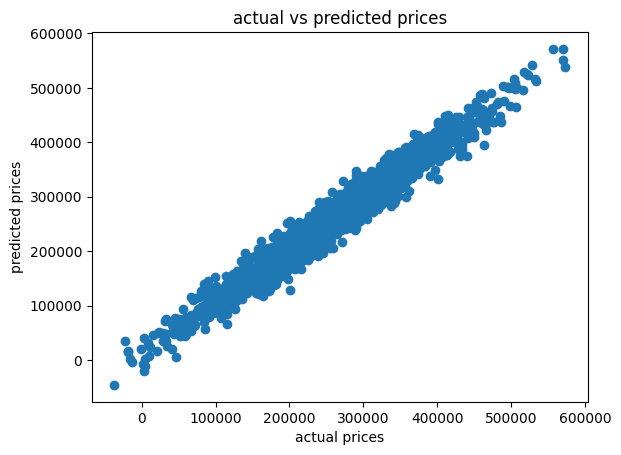

In [56]:
plt.scatter(y_test,preditctions)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual vs predicted prices")
plt.show()

MODEL SAVED

In [59]:
import joblib
joblib.dump(model,"housing.pkl")

['housing.pkl']

In [60]:
loaded_model = joblib.load("housing.pkl")

Load Data -> Inspect Data-> Separate X and y -> Train/Test Split -> Create Model -> Train Model -> Predict -> Evaluate -> Save Model